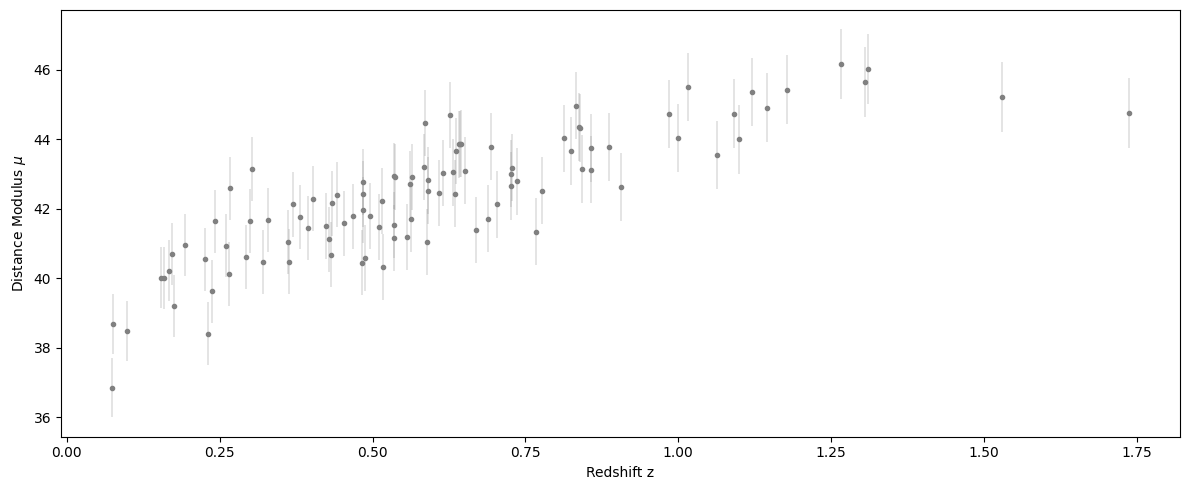

In [500]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from astroML.datasets import generate_mu_z
def Load_Dataset(nSamples):
    z_sample, mu_sample, dmu = generate_mu_z(nSamples, random_state=1234)
    return z_sample, mu_sample, dmu

z_sample, mu_sample, dmu = Load_Dataset(100)
plt.figure(figsize=(12,5), tight_layout=True)
plt.errorbar(z_sample, mu_sample, dmu, marker='o', c='gray', lw=0, markersize=3, elinewidth=0.3)#,label='data')
plt.xlabel("Redshift z")
_ = plt.ylabel(r"Distance Modulus $\mu$")

Tasks

- First, explore fitting this data with the tecniques we have seen.
- Start from linear regression and polynomial regression
- For the case of polynomial regression, just fit many of them for now.
- Let's bet based on intuition! Which fit is the best?

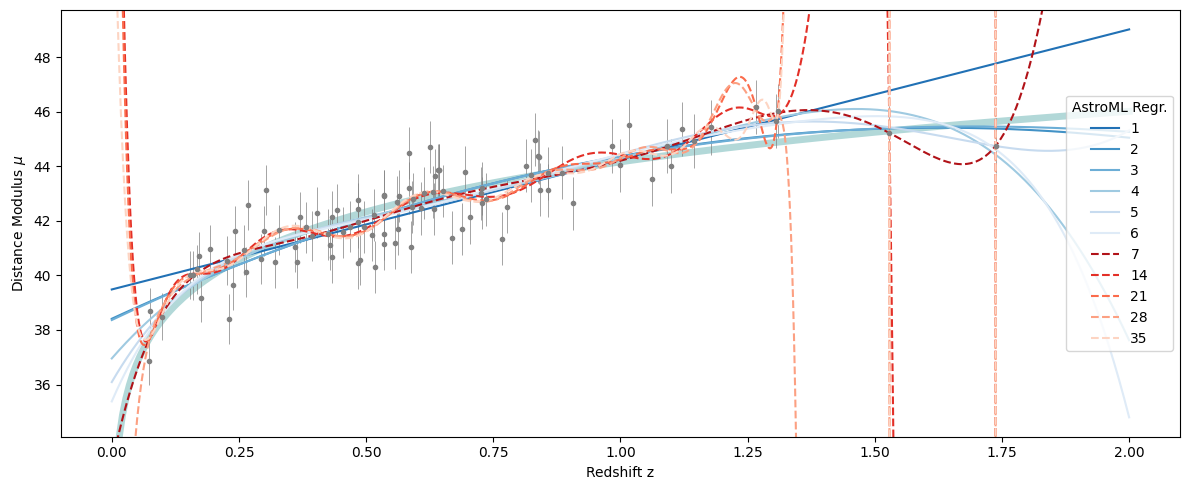

In [151]:
from astroML.linear_model import LinearRegression, PolynomialRegression

zSample, muSample, dMu = Load_Dataset(100)

zGrid = np.linspace(0, 2, 1000)
plt.figure(figsize=(12,5), tight_layout=True)
plt.errorbar(zSample, muSample, yerr=dMu, c='gray', lw=0, elinewidth=0.5, marker='o', markersize=3) #, label='Data')

Z = np.reshape(zSample, (-1,1))
import seaborn as sns
Palette = sns.color_palette('Blues_r', as_cmap=False, n_colors=7)

model = LinearRegression().fit(Z, muSample, dMu)
plt.plot(zGrid, model.predict(np.reshape(zGrid, (-1,1))), c=Palette[1], label='1')

for deg in np.arange(2, 7, 1, dtype=int):
    model = PolynomialRegression(degree=deg).fit(Z, muSample, dMu)
    plt.plot(zGrid, model.predict(np.reshape(zGrid, (-1,1))), c=Palette[deg], label=str(deg))

plt.ylim(plt.gca().get_ylim())

Higher_Degs = np.arange(7, 35+7, 7, dtype=int)
Palette = sns.color_palette('Reds_r', as_cmap=False, n_colors=len(Higher_Degs))
for jj, deg in enumerate( Higher_Degs ):
    model = PolynomialRegression(degree=deg).fit(Z, muSample, dMu)
    plt.plot(zGrid, model.predict(np.reshape(zGrid, (-1,1))), c=Palette[jj], label=str(deg), ls='--')

plt.xlabel('Redshift z')
plt.ylabel(r'Distance Modulus $\mu$')
plt.legend(title='AstroML Regr.', loc='center right')

from astropy.cosmology import Planck18
import astropy.units as u
zGrid = np.linspace(1e-3, 2, 300)
mu = 5*np.log10(Planck18.luminosity_distance(zGrid).to(u.pc).value) - 5
_ = plt.plot(zGrid, mu, c='teal', lw=5, alpha=0.3, zorder=-1)

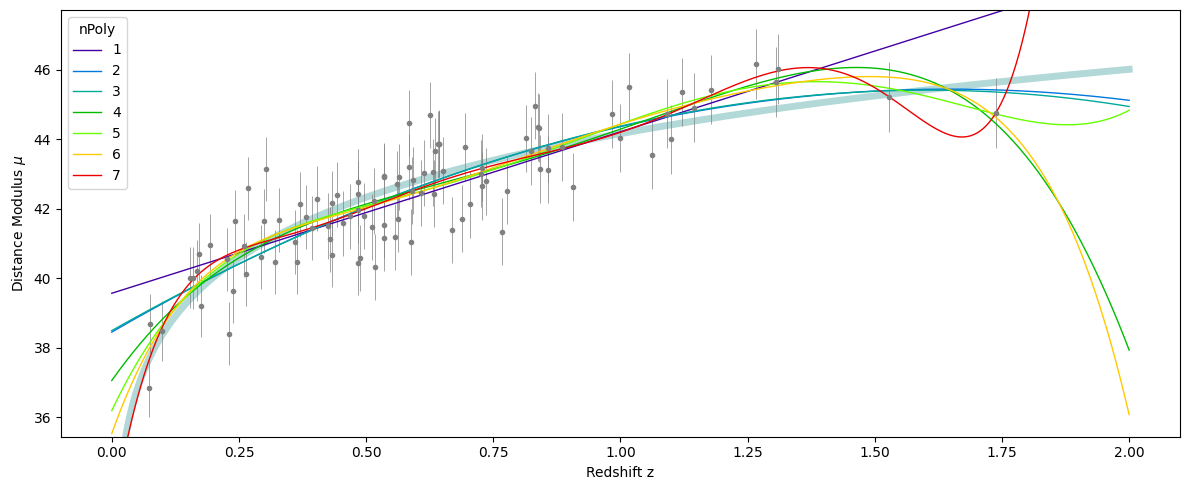

In [158]:
zSample, muSample, dMu = Load_Dataset(100)

zGrid = np.linspace(0, 2, 1000)
plt.figure(figsize=(12,5), tight_layout=True)
plt.errorbar(zSample, muSample, yerr=dMu, c='gray', lw=0, elinewidth=0.5, marker='o', markersize=3) #, label='Data')
plt.ylim(plt.gca().get_ylim())

Palette = sns.color_palette('nipy_spectral', as_cmap=False, n_colors=7)
for jj, deg in enumerate(np.arange(1, 8, 1, dtype=int)):
    theta = np.polyfit(zSample, muSample, deg)
    mu    = np.polyval(theta, zGrid)
    plt.plot(zGrid, mu, label=deg, color=Palette[jj], lw=1)
    
plt.xlabel(r'Redshift z')
plt.ylabel(r'Distance Modulus $\mu$')
_ = plt.legend(title='nPoly')
zGrid = np.linspace(1e-3, 2, 300)
mu = 5*np.log10(Planck18.luminosity_distance(zGrid).to(u.pc).value) - 5
_ = plt.plot(zGrid, mu, c='teal', lw=5, alpha=0.3, zorder=-1)

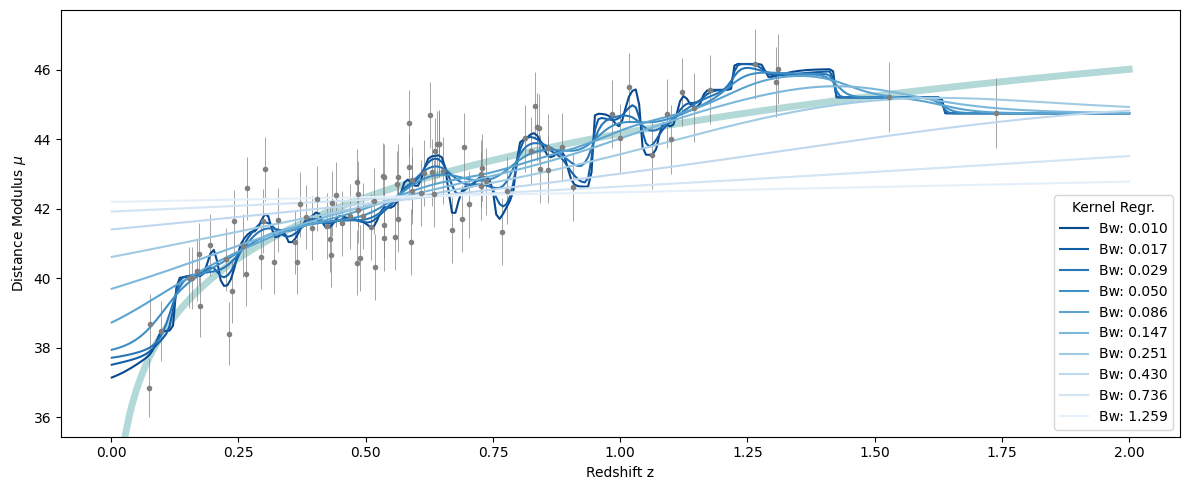

In [159]:
zSample, muSample, dMu = Load_Dataset(100)

plt.figure(figsize=(12,5), tight_layout=True)
plt.errorbar(zSample, muSample, yerr=dMu, c='gray', lw=0, elinewidth=0.5, marker='o', markersize=3) #, label='Data')
plt.ylim(plt.gca().get_ylim())
from astroML.linear_model import NadarayaWatson

bwRange = np.round(np.logspace(-2.0, 0.1, 10), 3)
Palette = sns.color_palette('Blues_r', as_cmap=False, n_colors = len(bwRange))
for jj, bw in enumerate(bwRange):
    regressor = NadarayaWatson('gaussian', bw)
    regressor.fit(zSample[:, None], muSample)
    mu_fit = regressor.predict(zGrid[:, None])
    plt.plot(zGrid, mu_fit,label='Bw: {0:.3f}'.format(bw), c=Palette[jj])

plt.xlabel(r'Redshift z')
plt.ylabel(r'Distance Modulus $\mu$')
_ = plt.legend(title='Kernel Regr.', loc='lower right')

zGrid = np.linspace(1e-3, 2, 300)
mu = 5*np.log10(Planck18.luminosity_distance(zGrid).to(u.pc).value) - 5
_ = plt.plot(zGrid, mu, c='teal', lw=5, alpha=0.3, zorder=-1)

"By eye", the 5th or 6th degree polynomials seem to capture the position of the high-z points a little more efficiently than the lower-degree models. However, as we get to higher and higher polynomials, the model variance becomes "a little extreme", hence I was forced to "lock" the y-axis in place.

As far as the underfitting is concerned, I am pretty certain (cosmology aside) that the linear model is underfitting the data.

On the other hand, it is evident that high order polynomials are predicting the position of some 1A SNe that would make no sense: hence, we are probably (to use an understatement) overfitting there.

---

As far as the Kernel Regression is concerned, the algorithm and the underlying methodology is completely different. A sufficiently small bandwidth is able to capture the $\mu$ fluctuations much better than a polynomial regression. However, one can safely say that this is NOT a good fit: in fact, it is extremely likely that the function is overfitting the data, and _significantly_ at that.

---

_I added the thick Teal line to plot one of our best model curves, which is derived by assuming a cosmology._

The presence of the last few points affects the behavior of the polynomial curve significantly. I would add that a curve that drops at high z would mean that a type 1A SNe at z$\approx$2 would be at the same distance-modulus of a type 1A SNe at z$\approx$0.1, which does not look good!

---

One can now try and check whether these affirmations are true, in a quantitatively way.

- In what cases are you underfitting the data?
- In what cases are you overfitting the data?

- Split the data into training and validation sets
- Implement a cross-validation procedure
- Pick the best!
- Does it agree with our bets?
- Repeat with Basis Function Regression and Kernel Regression
- Explore what happens when you change the number of datapoints and plot the resulting learning curves.

(240,) (60,)


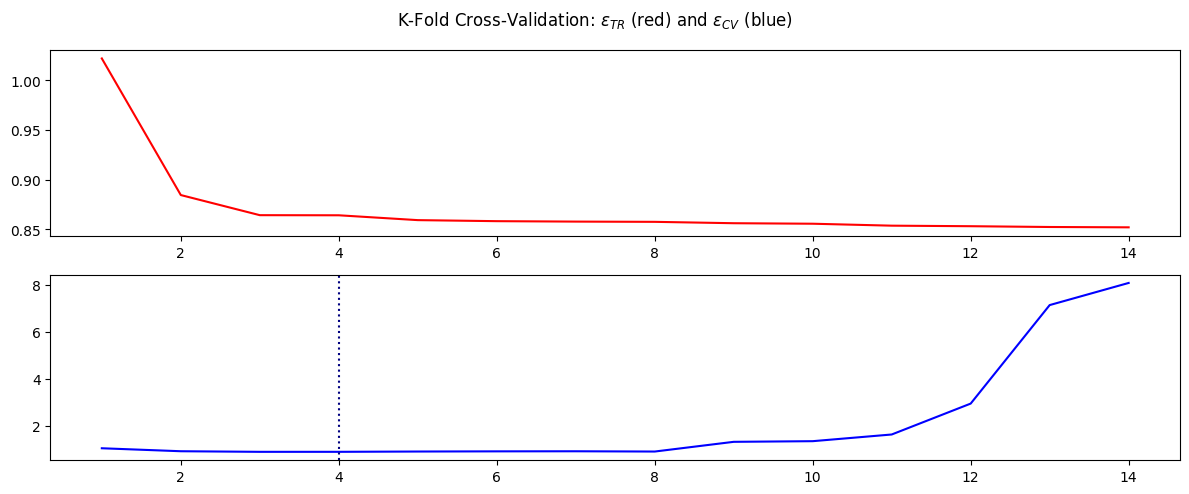

In [393]:
zSample, muSample, dMu = Load_Dataset(300)
zGrid = np.linspace(1e-3, 2, 1000)
fig, axs = plt.subplots(2,1, figsize=(12,5), tight_layout=True, sharey=False)

from sklearn.model_selection import LearningCurveDisplay, GridSearchCV
from sklearn.pipeline import make_pipeline

def Epsilon(yPoly, yTrue):
    Sum1 = yPoly - yTrue
    err = 1/len(yPoly) * np.sum(Sum1**2)
    return err**0.5

K = 5 # K-fold CV
zSplit  = np.split(zSample,  K)
muSplit = np.split(muSample, K)

import warnings
warnings.filterwarnings("ignore") ### ruthless, but effective
nMax = 15
degRange = np.arange(1, nMax, 1, dtype=int)
eTr = np.ones(nMax)
eCv = np.ones(nMax)
for deg in degRange:
    epsTr = 0
    epsCv = 0
    for j in range(0, K, 1):
        CV    = ( j == np.arange(0, K, 1, dtype=int) )
        ### Train = ( j != np.arange(0, K, 1, dtype=int) )
        zTr   = np.concatenate([z  for i, z  in enumerate(zSplit)  if i != j])
        zCv   = zSplit[j]
        muTr  = np.concatenate([mu for i, mu in enumerate(muSplit) if i != j])
        muCv  = muSplit[j]
        if j == 0 and deg == 2: print(np.shape(zTr), np.shape(zCv))
        theta = np.polyfit(zTr, muTr, deg)
        yTr   = np.polyval(theta, zTr)
        yCv   = np.polyval(theta, zCv)
        epsTr = epsTr + Epsilon(yPoly=yTr, yTrue=muTr)
        epsCv = epsCv + Epsilon(yPoly=yCv, yTrue=muCv)
    eTr[deg] = epsTr/K # taking the mean value over the K-fold CV
    eCv[deg] = epsCv/K # taking the mean value over the K-fold CV
    
axs[0].plot(degRange, eTr[1:], c='r') #, marker='x', s=5)
axs[1].plot(degRange, eCv[1:], c='b') #, marker='d', s=5)

plt.axvline(degRange[np.argmin(eCv)], ls=':', c='navy')
#for ax in axs: ax.set_yscale('log')
_ = fig.suptitle(r'K-Fold Cross-Validation: $\epsilon_{TR}$ (red) and $\epsilon_{CV}$ (blue)')

I chose to apply the definition of $\epsilon_{TR/CV}$ to a 5-Fold cross-validation of a dataset. There are other sklearn techniques, but this works fine I think. 

As expected, the linear fit performs terribly: the training error is still high, and I can safely state that the linear model is biased.

I was saying that 5-6-7 as a polynomial degree was a decent bet: in fact, the errors on the training set and validation set are roughly comparable in that regime. Soon after that, as expected, the model variance explodes! Notice how the blue curve goes up by three orders of magnitude when $n \geq 8$: sure, I am fitting the training set more accurately, but the predictions of the polynomial on new data are absolutely terrible!

Similar considerations can be made for the BasicFunctionRegressor and the KernelRegressor, whose results are in the cells below.

(240,) (60,)
Best bw = 0.06952


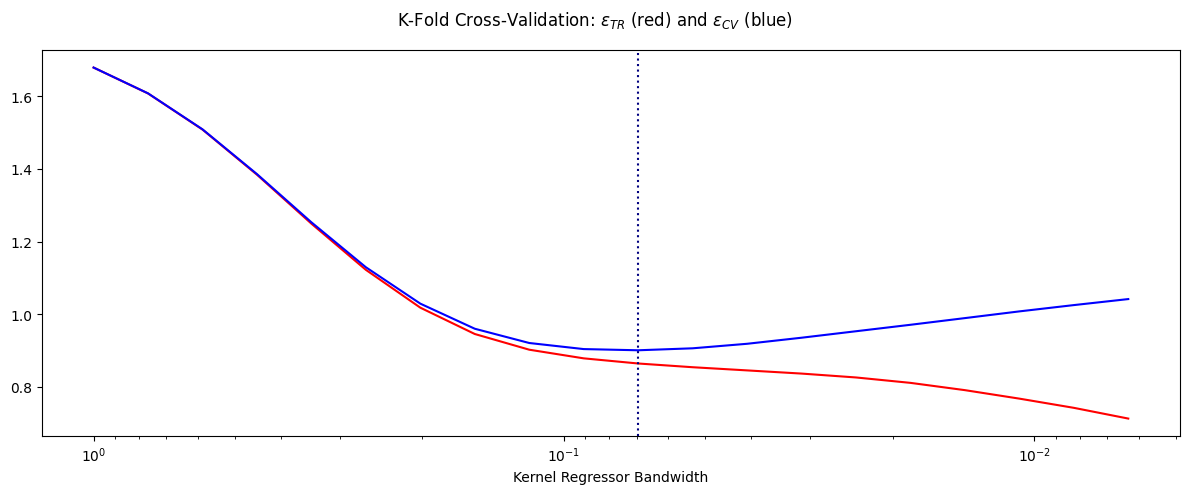

In [397]:
zSample, muSample, dMu = Load_Dataset(300)
zGrid = np.linspace(1e-3, 2, 1000)
plt.figure(figsize=(12,5), tight_layout=True)

K = 5 # K-fold CV
zSplit  = np.split(zSample,  K)
muSplit = np.split(muSample, K)

nMax = 20
eTr = np.ones(nMax)
eCv = np.ones(nMax)
bwRange = np.round(np.logspace(-2.2, 0.0, nMax), 5)

for jj, bw in enumerate(bwRange):
    epsTr = 0
    epsCv = 0
    regressor = NadarayaWatson('gaussian', bw)
    for j in range(0, K, 1):
        CV    = ( j == np.arange(0, K, 1, dtype=int) )
        #Train = ( j != np.arange(0, K, 1, dtype=int) )
        zTr   = np.concatenate([z  for i, z  in enumerate(zSplit)  if i != j])
        zCv   = zSplit[j]
        muTr  = np.concatenate([mu for i, mu in enumerate(muSplit) if i != j])
        muCv  = muSplit[j]
        if j == 0 and bw == bwRange[0]: print(np.shape(zTr), np.shape(zCv))
        regressor.fit(zTr[:, None], muTr)
        yTr   = regressor.predict(zTr[:, None])
        yCv   = regressor.predict(zCv[:, None])
        epsTr = epsTr + Epsilon(yPoly=yTr, yTrue=muTr)
        epsCv = epsCv + Epsilon(yPoly=yCv, yTrue=muCv)
    eTr[jj] = epsTr/K # taking the mean value over the K-fold CV
    eCv[jj] = epsCv/K # taking the mean value over the K-fold CV
    
plt.plot(bwRange, eTr, c='r') #, marker='x', s=5)
plt.plot(bwRange, eCv, c='b') #, marker='d', s=5)
plt.axvline(bwRange[np.argmin(eCv)], ls=':', c='navy')
print('Best bw =', bwRange[np.argmin(eCv)])
plt.xscale('log')
plt.xlabel('Kernel Regressor Bandwidth')
plt.gca().invert_xaxis()

_ = plt.suptitle(r'K-Fold Cross-Validation: $\epsilon_{TR}$ (red) and $\epsilon_{CV}$ (blue)')

(240,) (60,)
Best nGauss = 6


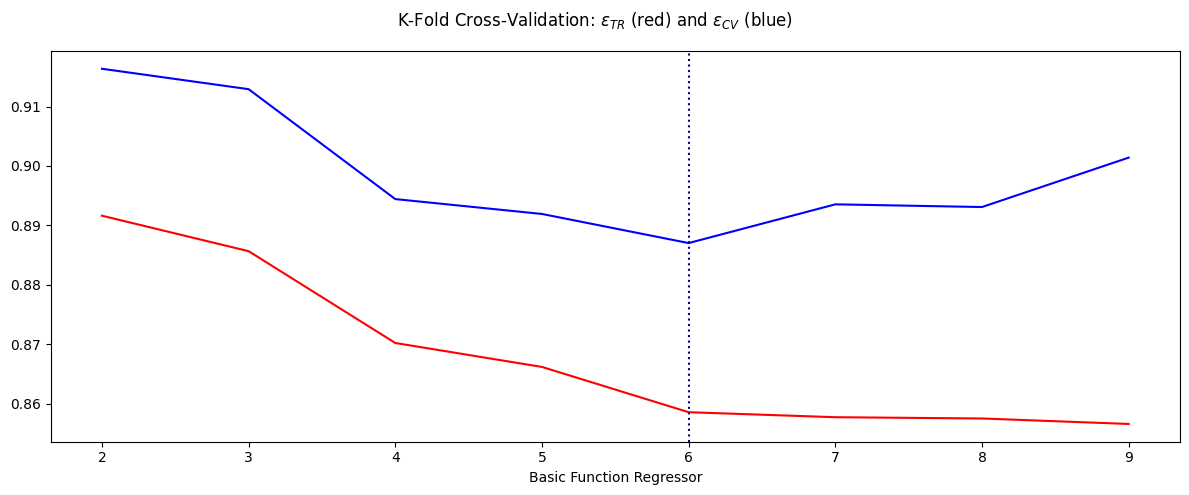

In [443]:
from astroML.linear_model import BasisFunctionRegression as BFR
zSample, muSample, dMu = Load_Dataset(300)
zGrid = np.linspace(1e-3, 2, 1000)
plt.figure(figsize=(12,5), tight_layout=True)

K = 5 # K-fold CV
zSplit  = np.split(zSample,  K)
muSplit = np.split(muSample, K)
dMuSplit= np.split(dMu, K)

nMax = 10
eTr = np.ones(nMax-2)
eCv = np.ones(nMax-2)
nRange = np.arange(2, nMax, 1, dtype=int)

for jj, n in enumerate(nRange):
    epsTr = 0
    epsCv = 0
    bMu    = np.linspace(0, 2, n)[:, None] ### setting the redshift range.
    bSigma = 1 * (bMu[1] - bMu[0])
    regressor = BFR('gaussian', mu=bMu, sigma=bSigma)
    for j in range(0, K, 1):
        CV    = ( j == np.arange(0, K, 1, dtype=int) )
        #Train = ( j != np.arange(0, K, 1, dtype=int) )
        zTr   = np.concatenate([z  for i, z  in enumerate(zSplit)  if i != j])
        zCv   = zSplit[j]
        muTr  = np.concatenate([mu for i, mu in enumerate(muSplit) if i != j])
        muCv  = muSplit[j]
        dmuTr = np.concatenate([mu for i, mu in enumerate(dMuSplit)if i != j])
        dmuCv = muSplit[j]
        if j == 0 and n == nRange[0]: print(np.shape(zTr), np.shape(zCv))
        regressor.fit(zTr[:, None], muTr, dmuTr)
        yTr   = regressor.predict(zTr[:, None])
        yCv   = regressor.predict(zCv[:, None])
        epsTr = epsTr + Epsilon(yPoly=yTr, yTrue=muTr)
        epsCv = epsCv + Epsilon(yPoly=yCv, yTrue=muCv)
    eTr[jj] = epsTr/K # taking the mean value over the K-fold CV
    eCv[jj] = epsCv/K # taking the mean value over the K-fold CV
    
plt.plot(nRange, eTr, c='r')
plt.plot(nRange, eCv, c='b')
plt.axvline(nRange[np.argmin(eCv)], ls=':', c='navy')
print('Best nGauss =', nRange[np.argmin(eCv)])
plt.xlabel('Basic Function Regressor')

_ = plt.suptitle(r'K-Fold Cross-Validation: $\epsilon_{TR}$ (red) and $\epsilon_{CV}$ (blue)')

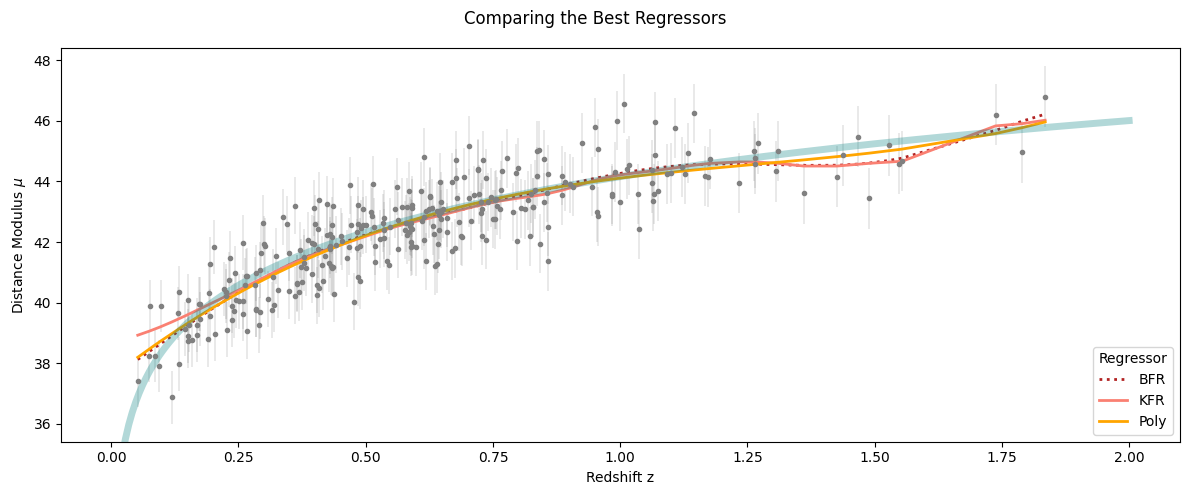

In [431]:
zSample, muSample, dMu = Load_Dataset(300)
sort = np.argsort(zSample)
zSample = zSample[sort]
muSample=muSample[sort]
dMu     = dMu    [sort]

plt.figure(figsize=(12,5), tight_layout=True)
plt.errorbar(zSample, muSample, yerr=dMu, c='gray', lw=0, elinewidth=0.25, marker='o', markersize=3) #, label='Data')
plt.ylim(plt.gca().get_ylim())

bMu    = np.linspace(0, 2, 6)[:, None] 
bSigma = 1 * (bMu[1] - bMu[0])
regressor = BFR('gaussian', mu=bMu, sigma=bSigma)
regressor.fit(zSample[:, None], muSample, dMu)
plt.plot(zSample, regressor.predict(zSample[:, None]), 
         c='firebrick', ls=':', lw=2, label='BFR')

regressor = NadarayaWatson('gaussian', 0.06952)
regressor.fit(zSample[:, None], muSample)
plt.plot(zSample, regressor.predict(zSample[:, None]), 
         c='salmon',    ls='-', lw=2, label='KFR')

theta = np.polyfit(zSample, muSample, 4)
plt.plot(zSample, np.polyval(theta, zSample), 
         c='orange',    ls='-', lw=2, label='Poly')

plt.xlabel(r'Redshift z')
plt.ylabel(r'Distance Modulus $\mu$')
_ = plt.legend(title='Regressor', loc='lower right')
plt.suptitle('Comparing the Best Regressors')

zGrid = np.linspace(1e-3, 2, 300)
mu = 5*np.log10(Planck18.luminosity_distance(zGrid).to(u.pc).value) - 5
_ = plt.plot(zGrid, mu, c='teal', lw=5, alpha=0.3)

Conclusions: it seems that the polynomial is not as good at capturing the behaviour of the z~1.5 dataset, like the other regressors. Of course, using a polynomial is less sophisticated!

- Explore what happens when you change the number of datapoints and plot the resulting learning curves.

Let's use the BEST models I got, and check what happens when I have a different number of datapoints in my training set. I'll pick a ~1000 set of SNe data and progressively feed it to the algorithms.

#Splits: [  2   4   5   8  10  20  25  40  50 100 125 200 250 500]


14it [00:01,  9.09it/s]
14it [00:28,  2.05s/it]
14it [00:02,  6.99it/s]


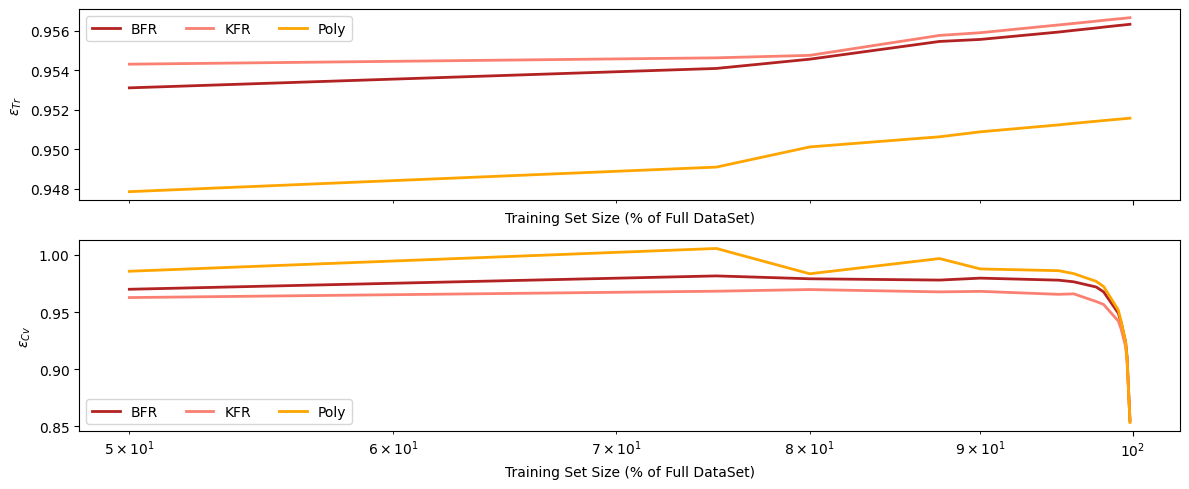

In [502]:
fig, axs = plt.subplots(2, 1, figsize=(12,5), tight_layout=True, sharex=True)

zSample, muSample, dMu = Load_Dataset(1000)

from sklearn.model_selection import train_test_split as TTS
kRange = np.arange(2, len(zSample), 1) # i could do len+1 an try a leave-one-out cross-validation, as well
kRange = kRange[np.where(len(zSample)%kRange==0)]
trSize = np.zeros(len(kRange))
print('#Splits:', kRange)
from tqdm import tqdm
def Learning_Curve(regressor, mode):
    eTr = np.ones(len(kRange))
    eCv = np.ones(len(kRange))
    for jj, K in tqdm(enumerate(kRange)):
        zSplit   = np.split(zSample,  K)
        muSplit  = np.split(muSample, K)
        dMuSplit = np.split(dMu, K)
        epsTr = 0
        epsCv = 0
        for j in range(0, K, 1):
            CV    = ( j == np.arange(0, K, 1, dtype=int) )
            #Train = ( j != np.arange(0, K, 1, dtype=int) )
            zTr   = np.concatenate([z  for i, z  in enumerate(zSplit)  if i != j])
            zCv   = zSplit[j]
            muTr  = np.concatenate([mu for i, mu in enumerate(muSplit) if i != j])
            muCv  = muSplit[j]
            dmuTr = np.concatenate([mu for i, mu in enumerate(dMuSplit)if i != j])
            dmuCv =dMuSplit[j]
            # if j == 0: print(len(zTr), len(zCv))
            if mode == 'BFR' or mode == 'Poly': 
                regressor.fit(zTr[:, None], muTr, dmuTr)
            if mode == 'KFR':
                regressor.fit(zTr[:, None], muTr)
            yTr   = regressor.predict(zTr[:, None])
            yCv   = regressor.predict(zCv[:, None])
            epsTr = epsTr + Epsilon(yPoly=yTr, yTrue=muTr)
            epsCv = epsCv + Epsilon(yPoly=yCv, yTrue=muCv)
        eTr[jj] = epsTr/K # taking the mean value over the K-fold CV
        eCv[jj] = epsCv/K # taking the mean value over the K-fold CV
        trSize[jj]= len(zTr)
    return eTr, eCv
    
bMu    = np.linspace(0, 2, 6)[:, None] 
bSigma = 1 * (bMu[1] - bMu[0])
regressorBFR    = BFR('gaussian', mu=bMu, sigma=bSigma)
regressorKernel = NadarayaWatson('gaussian', 0.06952)
regressorPoly   = PolynomialRegression(degree=4)

for reg, mode, col in zip( [regressorBFR, regressorKernel, regressorPoly],
                           ['BFR', 'KFR', 'Poly'],
                           ['firebrick', 'salmon', 'orange']):
    eTr, eCv = Learning_Curve(reg, mode)
    axs[0].plot(trSize/len(zSample)*100, eTr, c=col, lw=2, label=mode)
    axs[1].plot(trSize/len(zSample)*100, eCv, c=col, lw=2, label=mode)
    #break
for ax in axs: 
    ax.legend(ncol=3)
    ax.set_xlabel('Training Set Size (% of Full DataSet)')
    ax.set_xscale('log')
_ = axs[0].set_ylabel('$\epsilon_{Tr}$')
_ = axs[1].set_ylabel('$\epsilon_{Cv}$')

Conclusions: as expected, the training error increases with the size of the training set. On the other hand, the cross-validation error decreases with it.